SUBASRI R 24BAD116
Dataset Shape : (20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
Epoch 1/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.8413 - mae: 0.5995 - val_loss: 0.4176 - val_mae: 0.4708
Epoch 2/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3933 - mae: 0.4426 - val_loss: 0.3672 - val_mae: 0.4294
Epoch 3/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3681 - mae: 0.4280 - val_loss: 0.3558 - val_mae: 0.4405
Epoch 4/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step 

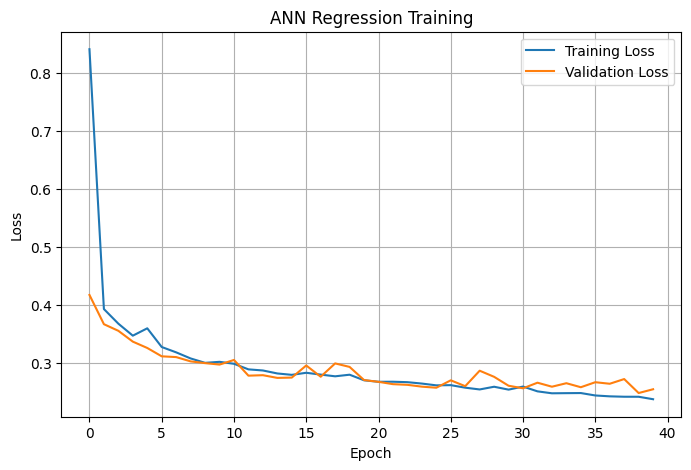


Sample Predictions
    Actual  Predicted
0  0.98800   0.784275
1  1.57200   1.278504
2  1.60900   1.393532
3  2.06500   2.245914
4  1.01700   1.085236
5  2.59400   2.541698
6  2.87500   1.755502
7  2.11300   2.643623
8  5.00001   4.877514
9  5.00001   4.505028


In [1]:

# EXPERIMENT 1 - PART A

print("SUBASRI R 24BAD116")

# Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

housing = fetch_california_housing(as_frame=True)

features = housing.data
target = housing.target

print("Dataset Shape :", features.shape)
print(features.head())


X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=21
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


network = tf.keras.Sequential()

network.add(tf.keras.layers.Input(shape=(8,)))

network.add(tf.keras.layers.Dense(
    units=128,
    activation="relu"
))

network.add(tf.keras.layers.Dense(
    units=64,
    activation="relu"
))

network.add(tf.keras.layers.Dense(
    units=16,
    activation="relu"
))

network.add(tf.keras.layers.Dense(
    units=1
))


network.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)


history = network.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=40,
    batch_size=64,
    verbose=1
)


prediction = network.predict(X_test)


mse = mean_squared_error(y_test, prediction)
mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mse)

print("\nEvaluation Metrics")
print("------------------------")
print("Mean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)


plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("ANN Regression Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


result = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": prediction.flatten()[:10]
})

print("\nSample Predictions")
print(result)

SUBASRI R 24BAD116
Dataset Shape : (569, 30)

Target Classes : ['malignant' 'benign']
Epoch 1/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8735 - loss: 0.4698 - val_accuracy: 0.8837 - val_loss: 0.3264
Epoch 2/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9471 - loss: 0.1978 - val_accuracy: 0.9070 - val_loss: 0.2063
Epoch 3/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.1145 - val_accuracy: 0.9302 - val_loss: 0.1716
Epoch 4/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9794 - loss: 0.0864 - val_accuracy: 0.9302 - val_loss: 0.1542
Epoch 5/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9824 - loss: 0.0664 - val_accuracy: 0.9419 - val_loss: 0.1418
Epoch 6/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9882 - loss: 0.0543 - val_accuracy: 0.9535 - val_loss: 0.1320
Epoch 7/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9971 - loss: 0.0439 - val_accuracy: 0.9535 - val_loss: 0.1301
Epoch 8/35
22/22 ━━━━━━━━━━━━━━

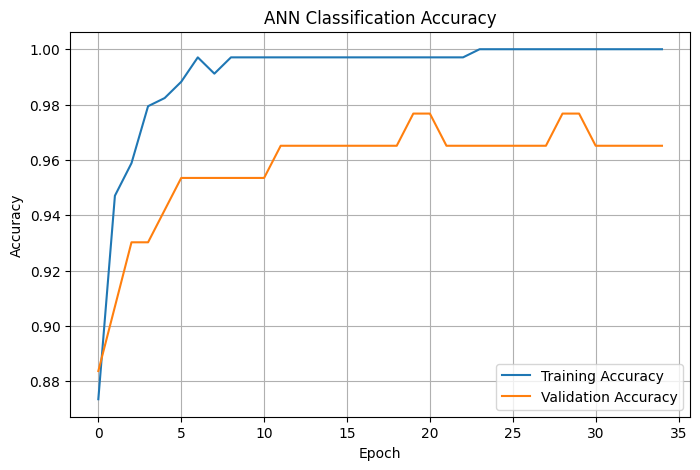

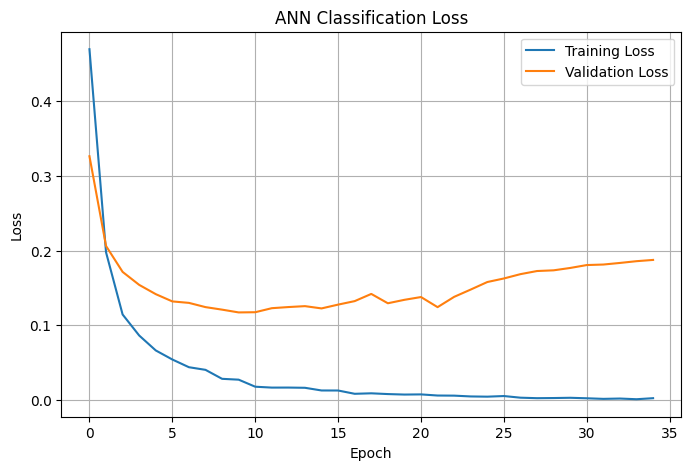

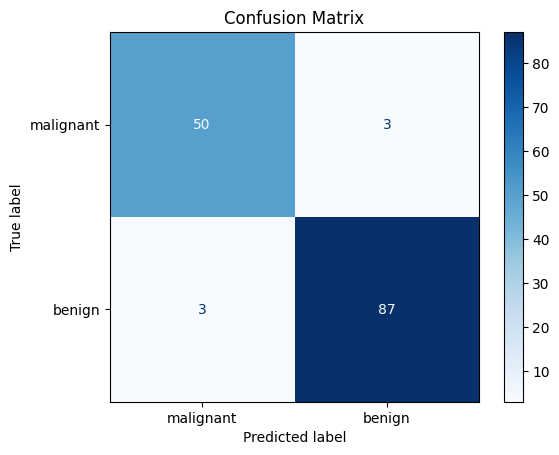


Sample Predictions
   Actual  Predicted
0       0          0
1       1          1
2       1          1
3       1          1
4       1          1
5       0          0
6       1          1
7       1          1
8       1          1
9       1          1


In [2]:

# EXPERIMENT 1 - PART B
print("SUBASRI R 24BAD116")
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load Dataset

cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = cancer.target

print("Dataset Shape :", X.shape)
print("\nTarget Classes :", cancer.target_names)

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=25,
    stratify=y
)

# Standardize Features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build Neural Network

classifier = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(30,)),

    tf.keras.layers.Dense(
        96,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        48,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.20),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )

])

# Compile Model

classifier.compile(

    optimizer=tf.keras.optimizers.Adam(),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

# Train Model

history = classifier.fit(

    X_train,

    y_train,

    epochs=35,

    batch_size=16,

    validation_split=0.20,

    verbose=1

)

# Prediction
probability = classifier.predict(X_test)

predicted = (probability > 0.5).astype(int)

# Performance Evaluation

acc = accuracy_score(y_test, predicted)

pre = precision_score(y_test, predicted)

rec = recall_score(y_test, predicted)

f1 = f1_score(y_test, predicted)

cm = confusion_matrix(y_test, predicted)


print("CLASSIFICATION PERFORMANCE")


print("Accuracy  :", round(acc,4))
print("Precision :", round(pre,4))
print("Recall    :", round(rec,4))
print("F1 Score  :", round(f1,4))

print("\nConfusion Matrix\n")
print(cm)


plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Classification Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Classification Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.show()


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()


results = pd.DataFrame({

    "Actual": y_test[:10],

    "Predicted": predicted.flatten()[:10]

})

print("\nSample Predictions")
print(results)